# Proyecto Final: Predicción de Daño en Aceras por Arbolado Urbano (NYC)

### Censo de Árboles Callejeros 2015 - NYC Parks
El censo de árboles de 2015 fue la mayor iniciativa de ciencia ciudadana en la historia de NYC Parks. Los datos representan el estado de los árboles plantados a lo largo de las calles de la ciudad de Nueva York.

- **Dataset:** 2015 Street Tree Census - Tree Data
- **Objetivo:** Predecir si un árbol causará daño a la vereda o acera peatonal (`sidewalk`).
- **Tipo de problema:** Clasificación binaria supervisada (Target: `Damage` vs. `NoDamage`).
- **Hipótesis central:** El daño a las veredas depende principalmente del grosor del tronco (`tree_dbh`), problemas radiculares en el suelo y el entorno donde está plantado.
- **Fuente de datos:** https://data.cityofnewyork.us/Environment/2015-Street-Tree-Census-Tree-Data/uvpi-gqnh/about_data

---

## 1. Carga e Inspección Inicial



In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuraciones estéticas para que los gráficos se vean prolijos
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

In [2]:
# Carga de los datos originales del censo
df_raw = pd.read_csv('2015_Street_Tree_Census_-_Tree_Data_20260914.csv')

print(f"Dimensiones del dataset: {df_raw.shape[0]:,} filas y {df_raw.shape[1]} columnas")

Dimensiones del dataset: 683,788 filas y 45 columnas


In [3]:
# Vemos las primeras 5 filas para conocer cómo vienen los registros
df_raw.head()

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,steward,guards,sidewalk,user_type,problems,root_stone,root_grate,root_other,trunk_wire,trnk_light,trnk_other,brch_light,brch_shoe,brch_other,address,postcode,zip_city,community board,borocode,borough,cncldist,st_assem,st_senate,nta,nta_name,boro_ct,state,latitude,longitude,x_sp,y_sp,council district,census tract,bin,bbl
0,180683,348711,08/27/2015,3,0,OnCurb,Alive,Fair,Acer rubrum,red maple,NaN,NaN,NoDamage,TreesCount Staff,NaN,No,No,No,No,No,No,No,No,No,108-005 70 AVENUE,11375,Forest Hills,406,4,Queens,29,28,16,QN17,Forest Hills,4.073.900,New York,"40,72309177","-73,84421522","1.027.431,148","202.756,7687",29.00,739.00,4052307.00,4022210001.00
1,200540,315986,09/03/2015,21,0,OnCurb,Alive,Fair,Quercus palustris,pin oak,NaN,NaN,Damage,TreesCount Staff,Stones,Yes,No,No,No,No,No,No,No,No,147-074 7 AVENUE,11357,Whitestone,407,4,Queens,19,27,11,QN49,Whitestone,4.097.300,New York,"40,79411067","-73,81867946","1.034.455,701","228.644,8374",19.00,973.00,4101931.00,4044750045.00
2,204026,218365,09/05/2015,3,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,1or2,NaN,Damage,Volunteer,NaN,No,No,No,No,No,No,No,No,No,390 MORGAN AVENUE,11211,Brooklyn,301,3,Brooklyn,34,50,18,BK90,East Williamsburg,3.044.900,New York,"40,71758074","-73,9366077","1.001.822,831","200.716,8913",34.00,449.00,3338310.00,3028870001.00
3,204337,217969,09/05/2015,10,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,NaN,NaN,Damage,Volunteer,Stones,Yes,No,No,No,No,No,No,No,No,1027 GRAND STREET,11211,Brooklyn,301,3,Brooklyn,34,53,18,BK90,East Williamsburg,3.044.900,New York,"40,71353749","-73,93445616","1.002.420,358","199.244,2531",34.00,449.00,3338342.00,3029250001.00
4,189565,223043,08/30/2015,21,0,OnCurb,Alive,Good,Tilia americana,American linden,NaN,NaN,Damage,Volunteer,Stones,Yes,No,No,No,No,No,No,No,No,603 6 STREET,11215,Brooklyn,306,3,Brooklyn,39,44,21,BK37,Park Slope-Gowanus,3.016.500,New York,"40,66677776","-73,97597938","990.913,775","182.202,426",39.00,165.00,3025654.00,3010850052.00


In [4]:
# Revisamos los tipos de datos de cada columna y si faltan valores
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 683788 entries, 0 to 683787
Data columns (total 45 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   tree_id           683788 non-null  int64  
 1   block_id          683788 non-null  int64  
 2   created_at        683788 non-null  str    
 3   tree_dbh          683788 non-null  int64  
 4   stump_diam        683788 non-null  int64  
 5   curb_loc          683788 non-null  str    
 6   status            683788 non-null  str    
 7   health            652172 non-null  str    
 8   spc_latin         652169 non-null  str    
 9   spc_common        652169 non-null  str    
 10  steward           164350 non-null  str    
 11  guards            79866 non-null   str    
 12  sidewalk          652172 non-null  str    
 13  user_type         683788 non-null  str    
 14  problems          225844 non-null  str    
 15  root_stone        683788 non-null  str    
 16  root_grate        683788 non-nu

In [5]:
# Resumen numérico básico (promedios, mínimos, máximos)
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
tree_id,683788.00,365205.01,208122.09,3.00,186582.75,366214.50,546170.25,722694.00
block_id,683788.00,313793.10,114839.02,100002.00,221556.00,319967.00,404624.00,999999.00
tree_dbh,683788.00,11.28,8.72,0.00,4.00,9.00,16.00,450.00
stump_diam,683788.00,0.43,3.29,0.00,0.00,0.00,0.00,140.00
postcode,683788.00,10916.25,651.55,83.00,10451.00,11214.00,11365.00,11697.00
community board,683788.00,343.51,115.74,101.00,302.00,402.00,412.00,503.00
borocode,683788.00,3.36,1.17,1.00,3.00,4.00,4.00,5.00
cncldist,683788.00,29.94,14.33,1.00,19.00,30.00,43.00,51.00
st_assem,683788.00,50.79,18.97,23.00,33.00,52.00,64.00,87.00
st_senate,683788.00,20.62,7.39,10.00,14.00,21.00,25.00,36.00


### Conclusiones:

1. **Cantidad de datos:** Tenemos un total de **683.788 árboles** y **45 columnas** con información de cada uno. 
2. **Qué información tenemos a mano:**
   - **Medidas físicas:** el grosor del tronco (`tree_dbh`).
   - **Estado del árbol:** si está vivo o muerto (`status`), su salud (`health`) y qué especie es (`spc_common`).
   - **Problemas en el suelo:** si las raíces chocan con piedras (`root_stone`), rejas (`root_grate`), etc.
   - **Lo que queremos predecir (nuestro objetivo):** el estado de la vereda (`sidewalk`), para saber si está rota o sana.
3. **Cosas raras que encontramos y hay que arreglar:**
   - **Árboles gigantes imposibles:** en el diámetro del tronco (`tree_dbh`) aparecen árboles de más de 400 pulgadas (más de 10 metros de ancho). Claramente son errores al cargar los datos y habrá que limpiarlos.
   - **Datos vacíos:** hay varias columnas con datos faltantes, pero parece que son de árboles secos o tocones cortados. En el paso siguiente lo vamos a revisar a fondo.

---

## 2. Análisis de Valores Faltantes (Nulos)



In [6]:
# 1. Conteo y porcentaje de nulos por columna
missing_series = (df_raw.isnull().mean() * 100)
missing_df = pd.DataFrame({
    'Nulos': df_raw.isnull().sum(),
    '% Faltantes': missing_series
}).loc[lambda d: d['Nulos'] > 0].sort_values('% Faltantes', ascending=False)

print(f"Total de celdas vacías en todo el dataset: {df_raw.isnull().sum().sum():,}")
print(f"Porcentaje global de datos vacíos: {df_raw.isnull().mean().mean() * 100:.2f}%\n")
missing_df

Total de celdas vacías en todo el dataset: 1,739,930
Porcentaje global de datos vacíos: 5.65%



,Nulos,% Faltantes
guards,603922,88.32
steward,519438,75.96
problems,457944,66.97
spc_latin,31619,4.62
spc_common,31619,4.62
health,31616,4.62
sidewalk,31616,4.62
bbl,9559,1.40
bin,9559,1.40
census tract,6519,0.95


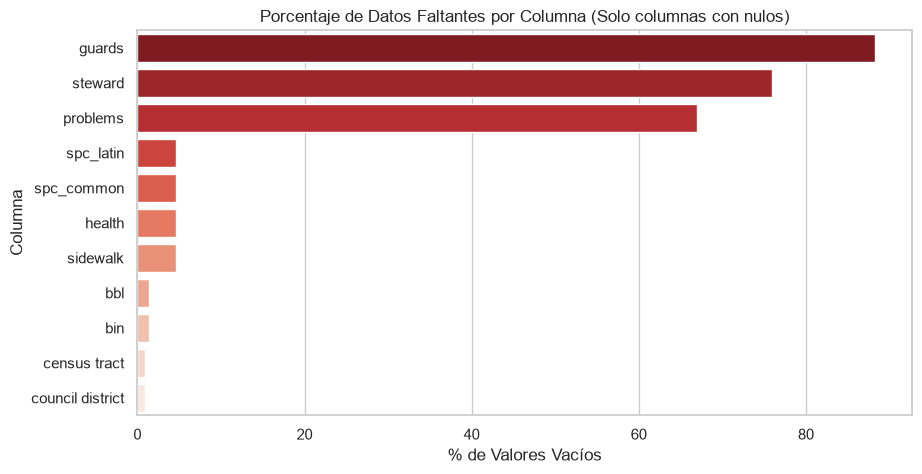

In [7]:
# 2. Gráfico de barras de columnas con datos faltantes
plt.figure(figsize=(10, 5))
sns.barplot(
    data=missing_df.reset_index(),
    x='% Faltantes',
    y='Columna' if 'Columna' in missing_df.columns else 'index',
    palette='Reds_r',
    hue='Columna' if 'Columna' in missing_df.columns else 'index',
    legend=False
)
plt.title('Porcentaje de Datos Faltantes por Columna (Solo columnas con nulos)')
plt.xlabel('% de Valores Vacíos')
plt.ylabel('Columna')
plt.show()

In [8]:
# 3. Comprobación lógica: ¿por qué faltan datos en sidewalk?
print("Relación entre el estado del árbol (status) y los nulos en la vereda (sidewalk):")
pd.crosstab(df_raw['status'], df_raw['sidewalk'].isnull(), rownames=['Estado (status)'], colnames=['¿Vereda es nula?'])

Relación entre el estado del árbol (status) y los nulos en la vereda (sidewalk):


¿Vereda es nula?,False,True
Estado (status),,
Alive,652172,1
Dead,0,13961
Stump,0,17654


### Conclusiones:

1. **El dataset está muy completo:** De las 45 columnas, solo 11 tienen datos vacíos. En general, más del 95% de todas las celdas tienen información.
2. **Las columnas más vacías tienen una explicación:**
   - `guards` (88% vacío): la mayoría de los árboles no tiene un protector metálico instalado.
   - `steward` (76% vacío): la mayoría no tiene un vecino o voluntario asignado para su cuidado.
   - `problems` (67% vacío): la gran mayoría de los árboles no tiene problemas ni plagas reportadas.
   - *Decisión:* Que el dato esté vacío en estas columnas significa en realidad "Ninguno" o "No tiene", no que se haya perdido la información.
3. **Por qué falta el dato de la vereda (`sidewalk`):**
   - Solo 1 árbol vivo no tiene el dato de la vereda. Los otros 31.615 datos vacíos corresponden al 100% de los árboles secos (`Dead`) y tocones talados (`Stump`).
   - Esto demuestra que los censistas no evaluaron el estado de la vereda si el árbol ya no estaba vivo. Por lo tanto, en el siguiente paso podemos quedarnos con los árboles vivos (`Alive`) con total tranquilidad.

---

## 3. Filtrado de Dominio y Creación del Target



In [9]:
# 1. Filtrado: nos quedamos solo con árboles vivos y vereda conocida
df = df_raw[(df_raw['status'] == 'Alive') & (df_raw['sidewalk'].notnull())].copy()

# 2. Creamos la variable objetivo (target): 1 para Daño, 0 para Sin Daño
df['target'] = (df['sidewalk'] == 'Damage').astype(int)

# 3. Conteo y porcentaje de registros conservados
print(f"Registros restantes: {df.shape[0]:,} de {df_raw.shape[0]:,} ({df.shape[0]/df_raw.shape[0]*100:.2f}% del original)")

# 4. Distribución del target en tabla
target_counts = df['target'].value_counts()
target_pct = df['target'].value_counts(normalize=True) * 100

pd.DataFrame({
    'Cantidad': target_counts,
    'Porcentaje (%)': target_pct,
    'Significado': ['No Dañada (0)', 'Dañada (1)']
})

Registros restantes: 652,172 de 683,788 (95.38% del original)


,Cantidad,Porcentaje (%),Significado
target,,,
0,464978,71.30,No Dañada (0)
1,187194,28.70,Dañada (1)


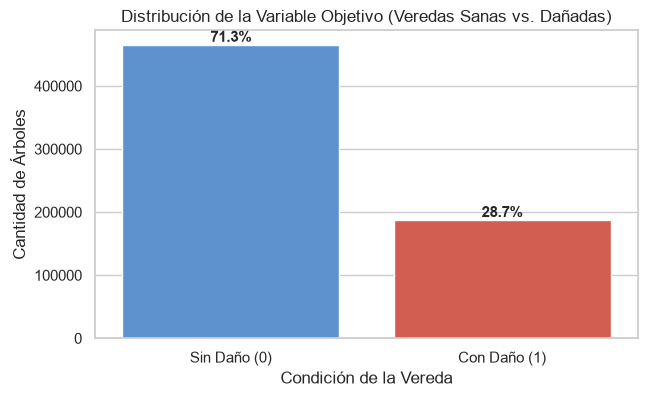

In [10]:
# 5. Gráfico de distribución de clases del target
plt.figure(figsize=(7, 4))
ax = sns.countplot(x='target', data=df, palette=['#4a90e2', '#e74c3c'], hue='target', legend=False)
plt.title('Distribución de la Variable Objetivo (Veredas Sanas vs. Dañadas)')
plt.xticks([0, 1], ['Sin Daño (0)', 'Con Daño (1)'])
plt.xlabel('Condición de la Vereda')
plt.ylabel('Cantidad de Árboles')

# Agregamos los porcentajes arriba de las barras
for p in ax.patches:
    pct = f"{100 * p.get_height() / len(df):.1f}%"
    ax.annotate(pct, (p.get_x() + p.get_width() / 2., p.get_height() + 5000),
                ha='center', weight='bold')

plt.show()

### Conclusiones:

1. **Conservamos casi todos los datos:** Nos quedan **652.172 árboles**, reteniendo un **95.38%** de los datos originales. La limpieza no afectó el tamaño ni la variedad de la muestra.
2. **Distribución de las veredas:**
   - **Sin Daño (0):** 464.978 veredas (**71.3%**).
   - **Con Daño (1):** 187.194 veredas (**28.7%**).


---

## 4. Tratamiento de Nulos Informativos y Outliers 



In [11]:
# 1. Imputación con sentido: el dato vacío significa "Ninguno / Sin intervención"
df['steward'] = df['steward'].fillna('None')
df['guards'] = df['guards'].fillna('None')
df['problems'] = df['problems'].fillna('None')

# 2. Análisis estadístico y percentiles de tree_dbh antes de limpiar
print("Estadísticas y percentiles del diámetro del tronco (tree_dbh):")
display(df['tree_dbh'].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99, 0.999]))

Estadísticas y percentiles del diámetro del tronco (tree_dbh):


count   652172.00
mean        11.71
std          8.63
min          0.00
1%           2.00
25%          5.00
50%         10.00
75%         16.00
99%         37.00
99.9%       47.00
max        425.00
Name: tree_dbh, dtype: float64

In [12]:
# 3. Conteo de valores imposibles
c_cero = (df['tree_dbh'] == 0).sum()
c_altos = (df['tree_dbh'] > 60).sum()
print(f"Árboles vivos con diámetro 0: {c_cero:,}")
print(f"Árboles con diámetro mayor a 60 pulgadas: {c_altos:,}")

# 4. Limpieza de outliers: conservamos árboles con diámetro entre 1 y 60 pulgadas
df_clean = df[(df['tree_dbh'] > 0) & (df['tree_dbh'] <= 60)].copy()

descartados = len(df) - len(df_clean)
print(f"\nRegistros descartados: {descartados:,}")
print(f"Registros limpios restantes: {len(df_clean):,} ({len(df_clean)/len(df)*100:.2f}% de los árboles vivos)")

Árboles vivos con diámetro 0: 222
Árboles con diámetro mayor a 60 pulgadas: 150

Registros descartados: 372
Registros limpios restantes: 651,800 (99.94% de los árboles vivos)


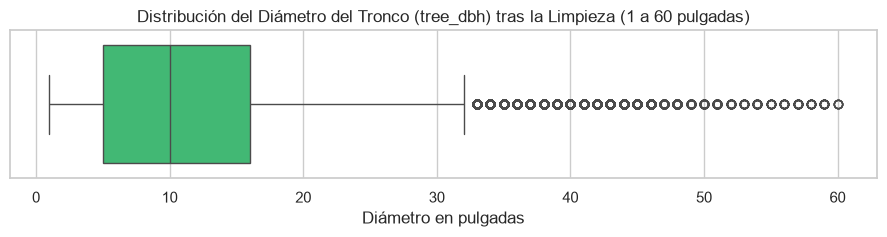

In [13]:
# 5. Boxplot del diámetro limpio
plt.figure(figsize=(9, 2.5))
sns.boxplot(x=df_clean['tree_dbh'], color='#2ecc71')
plt.title('Distribución del Diámetro del Tronco (tree_dbh) tras la Limpieza (1 a 60 pulgadas)')
plt.xlabel('Diámetro en pulgadas')
plt.tight_layout()
plt.show()

### Conclusiones:

1. **Nulos con significado resueltos:** Las columnas `steward`, `guards` y `problems` ahora tienen la categoría `'None'`, lo que le permite a los modelos interpretar explícitamente la ausencia de intervención humana o de problemas.
2. **El 99% de los árboles mide menos de 37 pulgadas:** La mitad de los árboles tiene 10 pulgadas o menos (~25 cm), y casi la totalidad mide menos de 37 pulgadas (~94 cm).
3. **Limpieza quirúrgica y casi sin pérdida de datos:**
   - Descartamos 222 árboles con diámetro 0 y 150 árboles con diámetros imposibles mayores a 60 pulgadas (que llegaban hasta 425 pulgadas por errores de tipeo).
   - En total solo se descartaron **372 registros**. Conservamos **651.800 árboles** (**99.94%** de la muestra viva), dejando los datos libres de distorsiones.

---

## 5. Análisis Exploratorio de Datos (EDA) - Relaciones con el Daño en Aceras


¿Cómo se relacionan las características del árbol y su entorno con el daño a la vereda (`target`)?

In [14]:
# 1. Agrupamos el diámetro en rangos lógicos de crecimiento
df_clean['dbh_binned'] = pd.cut(
    df_clean['tree_dbh'],
    bins=[0, 6, 12, 18, 24, 36, 60],
    labels=['0-6 pulg', '6-12 pulg', '12-18 pulg', '18-24 pulg', '24-36 pulg', '36-60 pulg']
)

# 2. Calculamos la tasa de daño por rango de diámetro
damage_by_size = df_clean.groupby('dbh_binned', observed=True)['target'].agg(
    Total='count',
    Tasa_Daño='mean'
).reset_index()
damage_by_size['% Daño'] = damage_by_size['Tasa_Daño'] * 100

print("Tasa de veredas rotas según el grosor del tronco:")
damage_by_size[['dbh_binned', 'Total', '% Daño']]

Tasa de veredas rotas según el grosor del tronco:


,dbh_binned,Total,% Daño
0,0-6 pulg,227432,15.42
1,6-12 pulg,181819,28.07
2,12-18 pulg,117895,39.14
3,18-24 pulg,62394,42.05
4,24-36 pulg,55735,45.62
5,36-60 pulg,6525,49.27


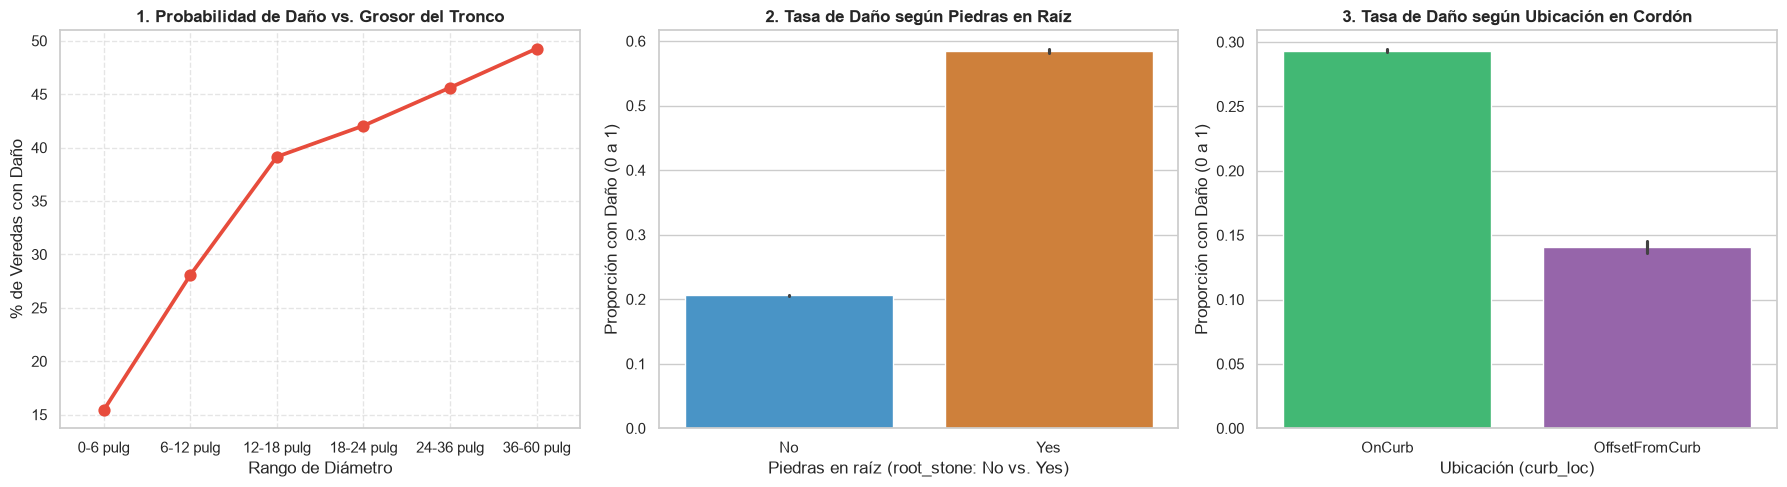

In [15]:
# 3. Gráficos exploratorios de las variables clave
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Daño vs Diámetro
sns.pointplot(data=damage_by_size, x='dbh_binned', y='% Daño', ax=axes[0], color='#e74c3c', markers='o')
axes[0].set_title("1. Probabilidad de Daño vs. Grosor del Tronco", fontsize=12, fontweight='bold')
axes[0].set_ylabel("% de Veredas con Daño")
axes[0].set_xlabel("Rango de Diámetro")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Gráfico 2: Daño vs Piedras en la raíz
sns.barplot(data=df_clean, x='root_stone', y='target', ax=axes[1], palette=['#3498db', '#e67e22'], hue='root_stone', legend=False)
axes[1].set_title("2. Tasa de Daño según Piedras en Raíz", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Proporción con Daño (0 a 1)")
axes[1].set_xlabel("Piedras en raíz (root_stone: No vs. Yes)")

# Gráfico 3: Daño vs Ubicación respecto al cordón
sns.barplot(data=df_clean, x='curb_loc', y='target', ax=axes[2], palette=['#2ecc71', '#9b59b6'], hue='curb_loc', legend=False)
axes[2].set_title("3. Tasa de Daño según Ubicación en Cordón", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Proporción con Daño (0 a 1)")
axes[2].set_xlabel("Ubicación (curb_loc)")

plt.tight_layout()
plt.show()

### Conclusiones:

1. **A mayor grosor, más veredas rotas:**
   - En árboles jóvenes (menos de 6 pulgadas), solo el **15.4%** de las veredas se rompe.
   - A medida que crece el árbol, la rotura aumenta de forma constante hasta alcanzar casi el **50%** en árboles de más de 36 pulgadas (el triple de daño que un árbol joven).
2. **Impacto de las piedras en las raíces (`root_stone`):**
   - Sin piedras en la raíz: **20.6%** de daño.
   - Con piedras en la raíz: salta al **58.4%**.
3. **Influencia de la ubicación en la vereda (`curb_loc`):**
   - Árboles retirados hacia adentro (`OffsetFromCurb`): **14.1%** de daño.
   - Árboles plantados justo en el cordón (`OnCurb`): **29.3%** de daño (más del doble).
---

## 6. Feature Engineering

### Objetivo:
Crear nuevas variables más informativas a partir de las columnas existentes: resumir los problemas de raíces, tronco y ramas en puntajes numéricos de conflicto, y reducir la gran cantidad de especies a las más representativas para que los modelos no se saturen.

In [20]:
# 1. Creamos puntajes de conflicto sumando problemas detectados (0 a 3)
root_cols = ['root_stone', 'root_grate', 'root_other']
df_clean['root_conflict_score'] = (df_clean[root_cols] == 'Yes').sum(axis=1)

trunk_cols = ['trunk_wire', 'trnk_light', 'trnk_other']
df_clean['trunk_conflict_score'] = (df_clean[trunk_cols] == 'Yes').sum(axis=1)

branch_cols = ['brch_light', 'brch_shoe', 'brch_other']
df_clean['branch_conflict_score'] = (df_clean[branch_cols] == 'Yes').sum(axis=1)

# 2. Reducimos las especies: Top 20 más frecuentes + 'Other'
top_20_species = df_clean['spc_latin'].value_counts().nlargest(20).index
df_clean['spc_clean'] = df_clean['spc_latin'].apply(
    lambda x: x if x in top_20_species else 'Other'
)

# 3. Verificamos cómo el puntaje de raíces predice el daño
print("Tasa de daño según el puntaje de conflicto en raíces (0 a 3):")
display(df_clean.groupby('root_conflict_score')['target'].agg(
    Total='count',
    Tasa_Daño='mean'
).reset_index())

Tasa de daño según el puntaje de conflicto en raíces (0 a 3):


,root_conflict_score,Total,Tasa_Daño
0,0,488129,0.20
1,1,153627,0.55
2,2,9969,0.62
3,3,75,0.39


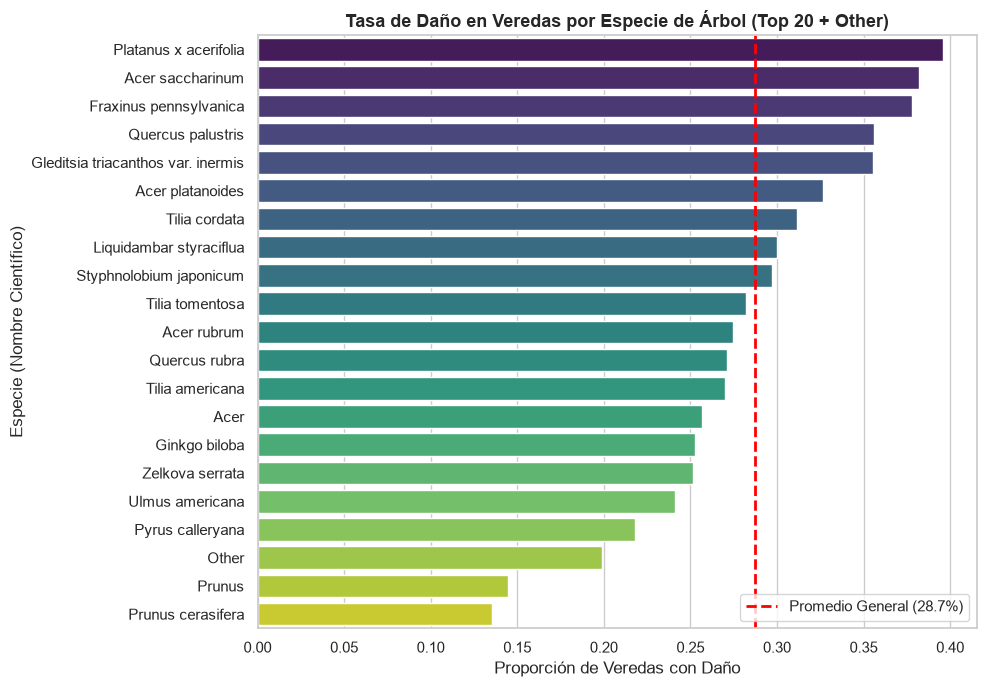

In [21]:
# 4. Gráfico: Tasa de daño por especie comparada contra el promedio general
species_damage = df_clean.groupby('spc_clean')['target'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 7))
sns.barplot(data=species_damage, y='spc_clean', x='target', palette='viridis')
plt.axvline(
    x=df_clean['target'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Promedio General ({df_clean["target"].mean()*100:.1f}%)'
)

plt.title('Tasa de Daño en Veredas por Especie de Árbol (Top 20 + Other)', fontsize=13, weight='bold')
plt.xlabel('Proporción de Veredas con Daño')
plt.ylabel('Especie (Nombre Científico)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Conclusiones:

1. **Puntajes numéricos de conflicto claros:** Consolidamos 9 columnas de texto dispersas en 3 variables continuas (`root_conflict_score`, `trunk_conflict_score`, `branch_conflict_score`), reduciendo el ruido para los modelos.
2. **El puntaje de raíces predice fuertemente:**
   - Sin problemas (`0`): solo **19.7%** de rotura.
   - Con un problema (`1`): salta al **55.1%**.
   - Con dos problemas (`2`): sube al **61.7%**.
3. **Especies con mayor y menor impacto:**
   - El **_Platanus x acerifolia_** (plátano de sombra común) tiene casi 87.000 ejemplares y lidera el ranking con casi el **40% de veredas dañadas** (muy por encima del promedio general).
   - Otras especies populares crecen de forma más armónica con la vereda, lo que demuestra que la especie del árbol es una característica clave para anticipar reparaciones.

---

## 7. Preprocesamiento y Partición de Datos (Train / Test)



In [18]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# 1. Definición de grupos de variables
features_num = ['tree_dbh', 'root_conflict_score', 'trunk_conflict_score', 'branch_conflict_score']
features_ord = ['steward', 'health']
features_nom = ['borough', 'guards', 'curb_loc', 'spc_clean']

X = df_clean[features_num + features_ord + features_nom]
y = df_clean['target']

# 2. Submuestreo estratificado a 100.000 filas para velocidad y eficiencia
X_sub, _, y_sub, _ = train_test_split(X, y, train_size=100000, random_state=42, stratify=y)

# 3. Partición Train (80%) / Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
)

print(f"Muestras para Entrenamiento (Train): {X_train.shape[0]:,}")
print(f"Muestras para Evaluación Final (Test): {X_test.shape[0]:,}")
print(f"Tasa de daño en Train: {y_train.mean()*100:.2f}%")
print(f"Tasa de daño en Test:  {y_test.mean()*100:.2f}%")

# 4. Definición de jerarquías para variables ordinales
steward_cats = ['None', '1or2', '3or4', '4orMore']
health_cats = ['Poor', 'Fair', 'Good']
categories_ord = [steward_cats, health_cats]

# 5. Preprocesador para modelos lineales (con escalado StandardScaler y OneHotEncoder con drop='first')
preprocessor_linear = ColumnTransformer(transformers=[
    ('num', StandardScaler(), features_num),
    ('ord', OrdinalEncoder(categories=categories_ord), features_ord),
    ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), features_nom)
])

# 6. Preprocesador para modelos de árboles (sin escalado 'passthrough' y OneHotEncoder completo)
preprocessor_tree = ColumnTransformer(transformers=[
    ('num', 'passthrough', features_num),
    ('ord', OrdinalEncoder(categories=categories_ord), features_ord),
    ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_nom)
])

print('\nPreprocesadores configurados con éxito: "preprocessor_linear" y "preprocessor_tree".')

Muestras para Entrenamiento (Train): 80,000
Muestras para Evaluación Final (Test): 20,000
Tasa de daño en Train: 28.71%
Tasa de daño en Test:  28.71%

Preprocesadores configurados con éxito: "preprocessor_linear" y "preprocessor_tree".


### Conclusiones:

1. **Partición equilibrada perfecta:** Tanto el conjunto de entrenamiento (80.000 árboles) como el de prueba (20.000 árboles) tienen exactamente un **28.71% de veredas rotas**. Al usar estratificación (`stratify`), nos aseguramos de que el azar no desbalancee los datos.
2. **Para Regresión Logística:** aplicamos `StandardScaler` a los números y `drop='first'` a las categorías, garantizando que el modelo converja bien sin que las variables de escalas grandes opaquen a las chicas.
3. **Para Árboles y Random Forest:** dejamos los números sin escalar (`passthrough`), ya que estos algoritmos toman decisiones basadas en condiciones de mayor/menor donde la escala no influye.

---

## 8. Modelo Base (Dummy Classifier)

### Objetivo:
Establecer el piso mínimo de rendimiento o "clasificador ingenuo". Si un modelo no aprende nada y simplemente predice siempre la clase mayoritaria ("Sin Daño / 0"), ¿qué porcentaje de aciertos obtiene? Cualquier modelo real de Machine Learning debe superar este piso para justificar su utilidad.

In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Entrenamos el Dummy Classifier (predice siempre la opción más frecuente: NoDamage)
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

# 2. Evaluamos en el conjunto de prueba (Test)
y_pred_dummy = dummy.predict(X_test)
dummy_acc = accuracy_score(y_test, y_pred_dummy)

print(f"Accuracy (Exactitud general) del Dummy Classifier: {dummy_acc*100:.2f}%\n")
print("Reporte detallado de métricas del Dummy Classifier:")
print(classification_report(
    y_test,
    y_pred_dummy,
    target_names=['Sin Daño (0)', 'Con Daño (1)'],
    zero_division=0
))

Accuracy (Exactitud general) del Dummy Classifier: 71.30%

Reporte detallado de métricas del Dummy Classifier:
              precision    recall  f1-score   support

Sin Daño (0)       0.71      1.00      0.83     14259
Con Daño (1)       0.00      0.00      0.00      5741

    accuracy                           0.71     20000
   macro avg       0.36      0.50      0.42     20000
weighted avg       0.51      0.71      0.59     20000



### Conclusiones simples de este paso:

1. **El piso mínimo es 71.30%:** Un modelo ingenuo que dice todo el tiempo *"la vereda está sana"* acierta el **71.30%** de las veces simplemente por probabilidad natural.
2. **La trampa del Accuracy en datos desbalanceados:**
   - Aunque obtiene un 71% general, al mirar el reporte descubrimos que para las veredas rotas (*Con Daño*) su precisión y captura (*recall*) es **0%**. No detecta ni un solo daño real.
3. **Criterio para los modelos siguientes:** En los pasos 9 y 10, nuestros modelos de Machine Learning no solo tienen que superar este 71.30%, sino que deben demostrar que son capaces de detectar veredas rotas de manera efectiva.

---